# 02 — Preprocessing (All 11 Activities)

Prepares the AdamSense dataset for training with all activity classes.  
Includes sliding window segmentation, normalization, and data augmentation.

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

In [2]:
# Paths
DATA_DIR = Path('../data')
RAW_PATH = DATA_DIR / 'raw' / 'AdamSense.csv'
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Sensor columns (wrist-mounted IMU)
SENSOR_COLS = ['Ax_w', 'Ay_w', 'Az_w', 'Gx_w', 'Gy_w', 'Gz_w']
NUM_FEATURES = len(SENSOR_COLS)

# Windowing
SAMPLING_RATE = 50       # Hz
WINDOW_SIZE = 128        # samples (~2.56s)
OVERLAP = 0.5            # 50% overlap
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))
LABEL_THRESHOLD = 0.75   # 75% majority required for window label

# Train/test split by user
TEST_USERS = [1, 2]
# Training users will be everything else

print(f'Window: {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE:.2f}s)')
print(f'Step: {STEP_SIZE} samples ({STEP_SIZE/SAMPLING_RATE:.2f}s)')
print(f'Features: {NUM_FEATURES} ({SENSOR_COLS})')

Window: 128 samples (2.56s)
Step: 64 samples (1.28s)
Features: 6 (['Ax_w', 'Ay_w', 'Az_w', 'Gx_w', 'Gy_w', 'Gz_w'])


## 2. Load and Inspect Data

In [3]:
df = pd.read_csv(RAW_PATH)
print(f'Total samples: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print(f'\nActivities ({df["Activity"].nunique()}):')
activity_counts = df['Activity'].value_counts()
for act, count in activity_counts.items():
    print(f'  {act:25s} {count:>8,} ({count/len(df)*100:.1f}%)')
print(f'\nUsers: {sorted(df["User"].unique())}')

Total samples: 709,582
Columns: ['Activity', 'Ax_p', 'Ax_w', 'Ay_p', 'Ay_w', 'Az_p', 'Az_w', 'GPS1_p', 'GPS2_p', 'Gx_p', 'Gx_w', 'Gy_p', 'Gy_w', 'Gz_p', 'Gz_w', 'Mx_p', 'Mx_w', 'My_p', 'My_w', 'Mz_p', 'Mz_w', 'PocketDev', 'Time_p', 'Time_w', 'User', 'WristDev']

Activities (11):
  nape_rubbing                67,859 (9.6%)
  knuckles_cracking           67,498 (9.5%)
  smoking                     66,937 (9.4%)
  ear_rubbing                 66,599 (9.4%)
  hair_pulling                65,973 (9.3%)
  forehead_rubbing            64,604 (9.1%)
  hand_scratching             64,490 (9.1%)
  nail_biting                 63,457 (8.9%)
  hand_tapping                63,220 (8.9%)
  sitting                     59,996 (8.5%)
  standing                    58,949 (8.3%)

Users: [2, 3, 5, 6, 7, 8, 10, 14, 15, 16]


## 3. Use ALL Activities

In [4]:
# Use all activities — sorted for reproducible label mapping
ALL_ACTIVITIES = sorted(df['Activity'].unique().tolist())
NUM_CLASSES = len(ALL_ACTIVITIES)
LABEL_MAP = {act: i for i, act in enumerate(ALL_ACTIVITIES)}

print(f'Using all {NUM_CLASSES} activities:')
for act, idx in LABEL_MAP.items():
    print(f'  {idx:2d}: {act}')

# Map labels to integers
df['label'] = df['Activity'].map(LABEL_MAP)
assert df['label'].isna().sum() == 0, 'Unmapped activities found'

Using all 11 activities:
   0: ear_rubbing
   1: forehead_rubbing
   2: hair_pulling
   3: hand_scratching
   4: hand_tapping
   5: knuckles_cracking
   6: nail_biting
   7: nape_rubbing
   8: sitting
   9: smoking
  10: standing


## 4. Sliding Window Extraction

In [5]:
def extract_windows(group_df, window_size, step_size, sensor_cols, label_threshold):
    """Extract fixed-size windows from a contiguous segment of data.
    
    Only keeps windows where a single activity dominates above label_threshold.
    """
    sensor_data = group_df[sensor_cols].values
    labels = group_df['label'].values
    n_samples = len(sensor_data)
    
    windows = []
    window_labels = []
    
    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size
        window_lab = labels[start:end]
        
        # Check label consistency
        counts = Counter(window_lab)
        dominant_label, dominant_count = counts.most_common(1)[0]
        
        if dominant_count / window_size >= label_threshold:
            windows.append(sensor_data[start:end])
            window_labels.append(dominant_label)
    
    return windows, window_labels


# Extract windows per user per activity (ensures contiguous segments)
all_windows = []
all_labels = []
all_users = []

for user in sorted(df['User'].unique()):
    for activity in ALL_ACTIVITIES:
        mask = (df['User'] == user) & (df['Activity'] == activity)
        segment = df.loc[mask]
        if len(segment) < WINDOW_SIZE:
            continue
        
        wins, labs = extract_windows(segment, WINDOW_SIZE, STEP_SIZE, SENSOR_COLS, LABEL_THRESHOLD)
        all_windows.extend(wins)
        all_labels.extend(labs)
        all_users.extend([user] * len(wins))

X_all = np.array(all_windows, dtype=np.float32)
y_all = np.array(all_labels, dtype=np.int32)
users_all = np.array(all_users)

print(f'Total windows: {len(X_all)}')
print(f'Shape: {X_all.shape}')  # (N, 128, 6)
print(f'\nPer-class distribution:')
for idx, act in enumerate(ALL_ACTIVITIES):
    count = np.sum(y_all == idx)
    print(f'  {idx:2d}: {act:25s} {count:>5d} ({count/len(y_all)*100:.1f}%)')

Total windows: 10927
Shape: (10927, 128, 6)

Per-class distribution:
   0: ear_rubbing                1027 (9.4%)
   1: forehead_rubbing            995 (9.1%)
   2: hair_pulling               1017 (9.3%)
   3: hand_scratching             993 (9.1%)
   4: hand_tapping                972 (8.9%)
   5: knuckles_cracking          1040 (9.5%)
   6: nail_biting                 977 (8.9%)
   7: nape_rubbing               1045 (9.6%)
   8: sitting                     923 (8.4%)
   9: smoking                    1032 (9.4%)
  10: standing                    906 (8.3%)


## 5. Train/Test Split (by User)

In [6]:
test_mask = np.isin(users_all, TEST_USERS)
train_mask = ~test_mask

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

print(f'Train: {X_train_raw.shape[0]} windows (users {sorted(set(users_all[train_mask]))})')
print(f'Test:  {X_test_raw.shape[0]} windows (users {sorted(set(users_all[test_mask]))})')

print(f'\nTrain class distribution:')
for idx, act in enumerate(ALL_ACTIVITIES):
    c = np.sum(y_train == idx)
    print(f'  {idx:2d}: {act:25s} {c:>5d}')

print(f'\nTest class distribution:')
for idx, act in enumerate(ALL_ACTIVITIES):
    c = np.sum(y_test == idx)
    print(f'  {idx:2d}: {act:25s} {c:>5d}')

Train: 9909 windows (users [3, 5, 6, 7, 8, 10, 14, 15, 16])
Test:  1018 windows (users [2])

Train class distribution:
   0: ear_rubbing                 926
   1: forehead_rubbing            896
   2: hair_pulling                906
   3: hand_scratching             897
   4: hand_tapping                895
   5: knuckles_cracking           918
   6: nail_biting                 896
   7: nape_rubbing                947
   8: sitting                     856
   9: smoking                     932
  10: standing                    840

Test class distribution:
   0: ear_rubbing                 101
   1: forehead_rubbing             99
   2: hair_pulling                111
   3: hand_scratching              96
   4: hand_tapping                 77
   5: knuckles_cracking           122
   6: nail_biting                  81
   7: nape_rubbing                 98
   8: sitting                      67
   9: smoking                     100
  10: standing                     66


## 6. Normalization (Z-score from training data)

In [7]:
# Compute stats from training data only (shape: (N, 128, 6) -> per-feature mean/std)
train_flat = X_train_raw.reshape(-1, NUM_FEATURES)
sensor_mean = train_flat.mean(axis=0)
sensor_std = train_flat.std(axis=0)
sensor_std[sensor_std < 1e-8] = 1.0  # prevent division by zero

print('Normalization parameters:')
for i, col in enumerate(SENSOR_COLS):
    print(f'  {col}: mean={sensor_mean[i]:.6f}, std={sensor_std[i]:.6f}')

# Apply normalization
X_train = (X_train_raw - sensor_mean) / sensor_std
X_test = (X_test_raw - sensor_mean) / sensor_std

print(f'\nX_train range: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'X_test  range: [{X_test.min():.2f}, {X_test.max():.2f}]')

Normalization parameters:
  Ax_w: mean=0.206971, std=0.577543
  Ay_w: mean=0.077704, std=0.494002
  Az_w: mean=-0.466794, std=0.388948
  Gx_w: mean=-0.918844, std=44.305416
  Gy_w: mean=1.710465, std=22.098326
  Gz_w: mean=0.144442, std=19.815891

X_train range: [-16.69, 21.02]
X_test  range: [-25.69, 28.86]


## 7. Data Augmentation Functions

These will be applied **on-the-fly during training** via a generator.  
We define them here and save them with the preprocessing info.

In [8]:
def augment_jitter(x, sigma=0.05):
    """Add random Gaussian noise."""
    return x + np.random.normal(0, sigma, x.shape).astype(np.float32)

def augment_scaling(x, sigma=0.1):
    """Scale each feature channel by a random factor."""
    factors = np.random.normal(1.0, sigma, (1, x.shape[1])).astype(np.float32)
    return x * factors

def augment_time_warp(x, sigma=0.2, num_knots=4):
    """Smooth temporal distortion using cubic interpolation."""
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])
    knot_positions = np.linspace(0, x.shape[0] - 1, num_knots + 2)
    knot_values = knot_positions + np.random.normal(0, sigma, len(knot_positions)).cumsum()
    knot_values = np.clip(knot_values, 0, x.shape[0] - 1)
    knot_values[0] = 0
    knot_values[-1] = x.shape[0] - 1
    cs = CubicSpline(knot_positions, knot_values)
    warped_steps = cs(orig_steps)
    warped_steps = np.clip(warped_steps, 0, x.shape[0] - 1)
    # Interpolate each channel
    result = np.zeros_like(x)
    for c in range(x.shape[1]):
        result[:, c] = np.interp(warped_steps, orig_steps, x[:, c])
    return result

def augment_rotation(x):
    """Apply a small random 3D rotation to accel and gyro independently."""
    def random_rotation_matrix(max_angle=15):
        angles = np.radians(np.random.uniform(-max_angle, max_angle, 3))
        cx, cy, cz = np.cos(angles)
        sx, sy, sz = np.sin(angles)
        Rx = np.array([[1, 0, 0], [0, cx, -sx], [0, sx, cx]])
        Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]])
        Rz = np.array([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]])
        return Rz @ Ry @ Rx
    
    result = x.copy()
    # Rotate accelerometer (cols 0-2)
    R_acc = random_rotation_matrix()
    result[:, :3] = (R_acc @ result[:, :3].T).T
    # Rotate gyroscope (cols 3-5)
    R_gyro = random_rotation_matrix()
    result[:, 3:6] = (R_gyro @ result[:, 3:6].T).T
    return result.astype(np.float32)

def augment_magnitude_warp(x, sigma=0.2, num_knots=4):
    """Smoothly vary the magnitude of the signal over time."""
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])
    knot_positions = np.linspace(0, x.shape[0] - 1, num_knots + 2)
    knot_values = np.random.normal(1.0, sigma, len(knot_positions))
    cs = CubicSpline(knot_positions, knot_values)
    warp = cs(orig_steps).astype(np.float32)
    return x * warp[:, np.newaxis]

def augment_permutation(x, n_segments=5):
    """Randomly permute temporal segments."""
    seg_len = x.shape[0] // n_segments
    segments = [x[i*seg_len:(i+1)*seg_len] for i in range(n_segments)]
    remainder = x[n_segments*seg_len:]
    np.random.shuffle(segments)
    if len(remainder) > 0:
        segments.append(remainder)
    return np.concatenate(segments, axis=0)[:x.shape[0]]


def apply_augmentation(x, p=0.5):
    """Apply a random subset of augmentations to a single window."""
    x = x.copy()
    if np.random.random() < p:
        x = augment_jitter(x, sigma=0.05)
    if np.random.random() < p:
        x = augment_scaling(x, sigma=0.1)
    if np.random.random() < p:
        x = augment_rotation(x)
    if np.random.random() < 0.3:
        x = augment_time_warp(x, sigma=0.2)
    if np.random.random() < 0.3:
        x = augment_magnitude_warp(x, sigma=0.2)
    if np.random.random() < 0.2:
        x = augment_permutation(x, n_segments=5)
    return x

# Quick sanity check
sample = X_train[0]
aug = apply_augmentation(sample)
print(f'Original shape: {sample.shape}, Augmented shape: {aug.shape}')
print('Augmentation functions defined successfully.')

Original shape: (128, 6), Augmented shape: (128, 6)
Augmentation functions defined successfully.


## 8. Offline Augmentation (Expand Training Set)

We augment the training set to **3x** its original size.  
The original samples are kept, plus 2 augmented copies of each.

In [11]:
NUM_AUG_COPIES = 2

X_aug_list = [X_train]  # keep originals
y_aug_list = [y_train]

for copy_idx in range(NUM_AUG_COPIES):
    print(f'Generating augmented copy {copy_idx + 1}/{NUM_AUG_COPIES}...')
    X_copy = np.array([apply_augmentation(X_train[i]) for i in range(len(X_train))], dtype=np.float32)
    X_aug_list.append(X_copy)
    y_aug_list.append(y_train.copy())

X_train_aug = np.concatenate(X_aug_list, axis=0)
y_train_aug = np.concatenate(y_aug_list, axis=0)

# Shuffle
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

print(f'\nOriginal training: {X_train.shape[0]} windows')
print(f'Augmented training: {X_train_aug.shape[0]} windows (3x)')
print(f'Test (unchanged): {X_test.shape[0]} windows')

Generating augmented copy 1/2...
Generating augmented copy 2/2...

Original training: 9909 windows
Augmented training: 29727 windows (3x)
Test (unchanged): 1018 windows


## 9. Visualize Augmentation

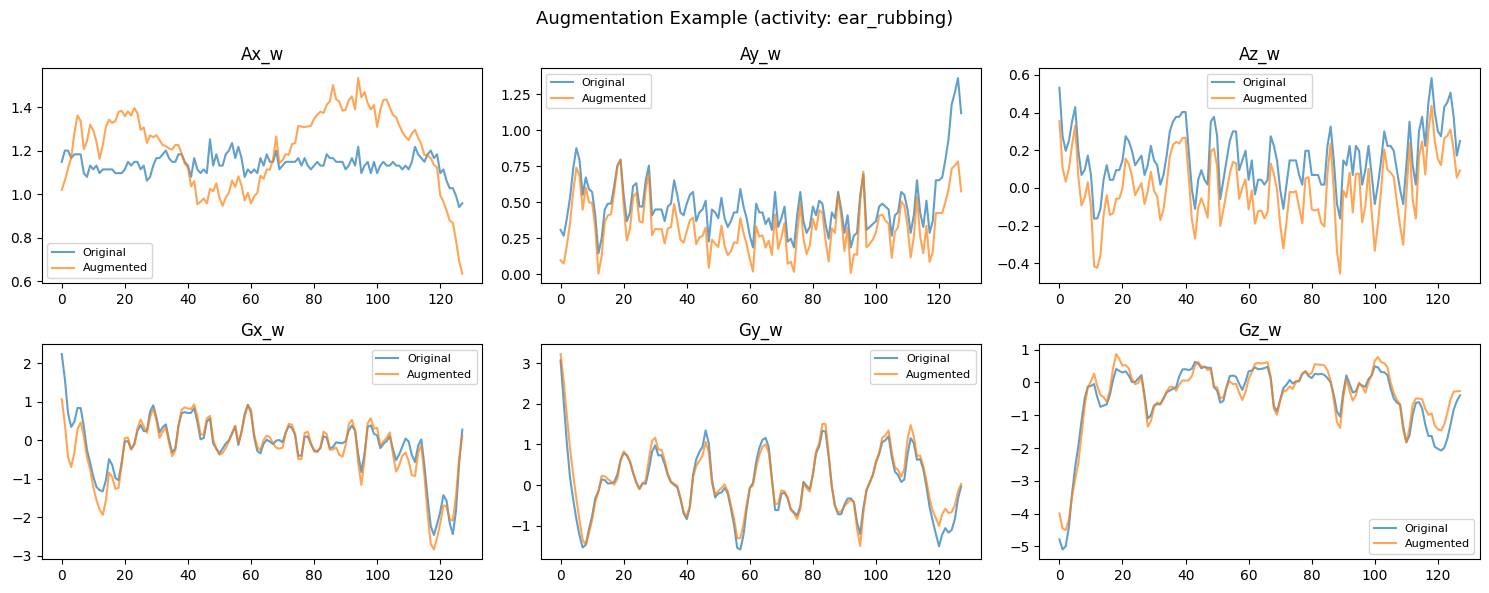

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
sample_idx = 0
orig = X_train[sample_idx]
aug_sample = apply_augmentation(orig)

for i, col in enumerate(SENSOR_COLS):
    ax = axes[i // 3, i % 3]
    ax.plot(orig[:, i], alpha=0.7, label='Original')
    ax.plot(aug_sample[:, i], alpha=0.7, label='Augmented')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle(f'Augmentation Example (activity: {ALL_ACTIVITIES[y_train[sample_idx]]})', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/exploration_outputs/augmentation_example.png', dpi=120)
plt.show()

## 10. Save Processed Data

In [13]:
# Save arrays
np.save(PROCESSED_DIR / 'X_train.npy', X_train_aug)
np.save(PROCESSED_DIR / 'y_train.npy', y_train_aug)
np.save(PROCESSED_DIR / 'X_test.npy', X_test)
np.save(PROCESSED_DIR / 'y_test.npy', y_test)

# Also save non-augmented versions for quantization calibration
np.save(PROCESSED_DIR / 'X_train_original.npy', X_train)
np.save(PROCESSED_DIR / 'y_train_original.npy', y_train)

# Save preprocessing info
preprocessing_info = {
    'sensor_columns': SENSOR_COLS,
    'num_features': NUM_FEATURES,
    'num_classes': NUM_CLASSES,
    'activities': ALL_ACTIVITIES,
    'label_map': LABEL_MAP,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'overlap': OVERLAP,
    'sampling_rate': SAMPLING_RATE,
    'sensor_mean': sensor_mean,
    'sensor_std': sensor_std,
    'test_users': TEST_USERS,
    'train_samples_original': len(X_train),
    'train_samples_augmented': len(X_train_aug),
    'test_samples': len(X_test),
    'label_threshold': LABEL_THRESHOLD,
    'num_aug_copies': NUM_AUG_COPIES,
}

with open(PROCESSED_DIR / 'preprocessing_info.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)

print('Saved files:')
for p in sorted(PROCESSED_DIR.glob('*')):
    size = p.stat().st_size
    unit = 'KB' if size < 1e6 else 'MB'
    val = size / 1024 if size < 1e6 else size / (1024*1024)
    print(f'  {p.name:35s} {val:>8.1f} {unit}')

Saved files:
  X_test.npy                               3.0 MB
  X_train.npy                             87.1 MB
  X_train_original.npy                    29.0 MB
  preprocessing_info.pkl                   0.8 KB
  y_test.npy                               4.1 KB
  y_train.npy                            116.2 KB
  y_train_original.npy                    38.8 KB


In [14]:
print('\n=== Preprocessing Complete ===')
print(f'Activities: {NUM_CLASSES}')
print(f'Train windows: {len(X_train_aug)} (augmented from {len(X_train)})')
print(f'Test windows: {len(X_test)}')
print(f'Window shape: ({WINDOW_SIZE}, {NUM_FEATURES})')
print(f'\nLabel mapping:')
for act, idx in LABEL_MAP.items():
    print(f'  {idx:2d}: {act}')


=== Preprocessing Complete ===
Activities: 11
Train windows: 29727 (augmented from 9909)
Test windows: 1018
Window shape: (128, 6)

Label mapping:
   0: ear_rubbing
   1: forehead_rubbing
   2: hair_pulling
   3: hand_scratching
   4: hand_tapping
   5: knuckles_cracking
   6: nail_biting
   7: nape_rubbing
   8: sitting
   9: smoking
  10: standing
